In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np

In [34]:
df = pd.read_csv(r"C:\Users\sneha\OneDrive\Documents\New folder\Google PlayStore Data\google_playstore_cleaned.csv")

In [35]:
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & Scrapbook,Art_And_Design,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,07-01-2018,1.0.0,4.0.3 and up
1,Coloring Book Moana,Art_And_Design,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,15-01-2018,2.0.0,4.0.3 and up
2,"U Launcher Lite – Free Live Cool Themes, Hide ...",Art_And_Design,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,01-08-2018,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,Art_And_Design,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,08-06-2018,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,Art_And_Design,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,20-06-2018,1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8887,Fr Calculator,Family,4.0,7,2.6,500,Free,0.0,Everyone,Education,18-06-2017,1.0.0,4.1 and up
8888,Sya9A Maroc - Fr,Family,4.5,38,53.0,5000,Free,0.0,Everyone,Education,25-07-2017,1.48,4.1 and up
8889,Fr. Mike Schmitz Audio Teachings,Family,5.0,4,3.6,100,Free,0.0,Everyone,Education,06-07-2018,1,4.1 and up
8890,The Scp Foundation Db Fr Nn5N,Books_And_Reference,4.5,114,14.0,1000,Free,0.0,Mature 17+,Books & Reference,19-01-2015,Varies with device,Varies with device


# Missing Values

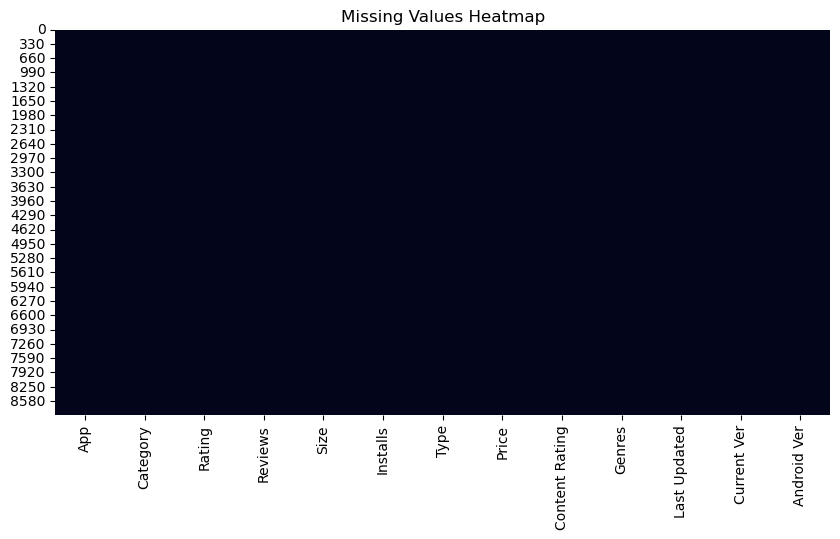

In [8]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

In [ ]:
# Insight

Most missing values exist in the Size column because many apps have "Varies with device."
Remaining features are nearly complete.

# Top 15 App Categories

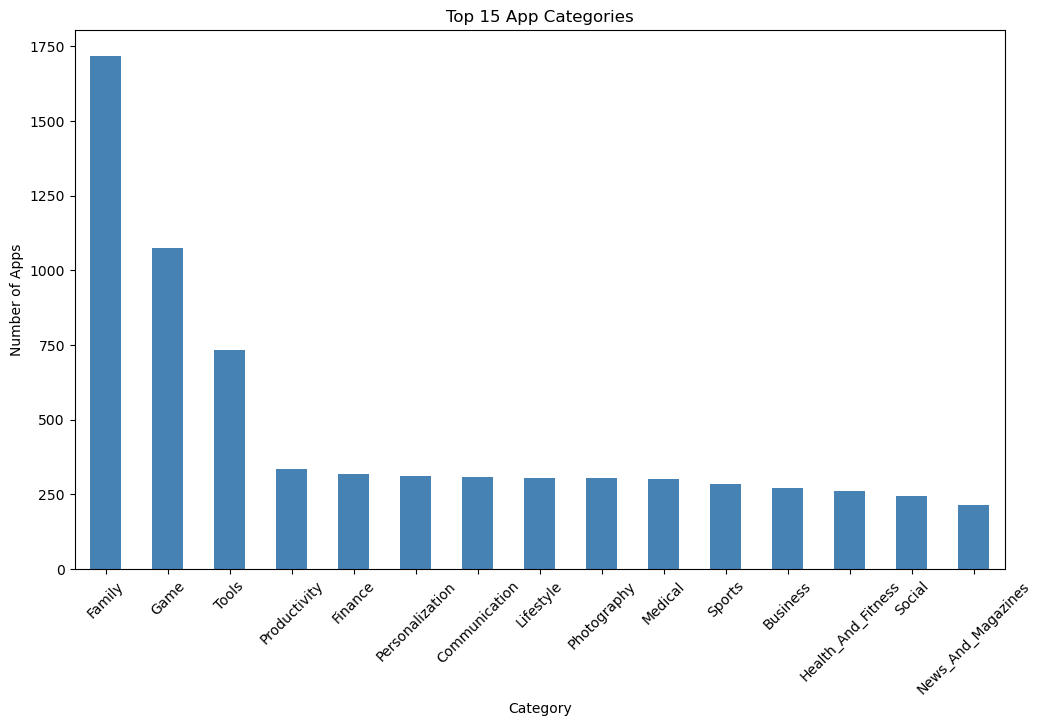

In [11]:


plt.figure(figsize=(12,7))

df["Category"].value_counts().head(15).plot(
    kind="bar",
    color="steelblue"
)

plt.title("Top 15 App Categories")

plt.xlabel("Category")

plt.ylabel("Number of Apps")

plt.xticks(rotation=45)

plt.show()

In [ ]:

# Business Insight

Categories with the largest number of apps indicate highly competitive markets.
New developers may find it harder to stand out in these categories.

# Rating Distribution

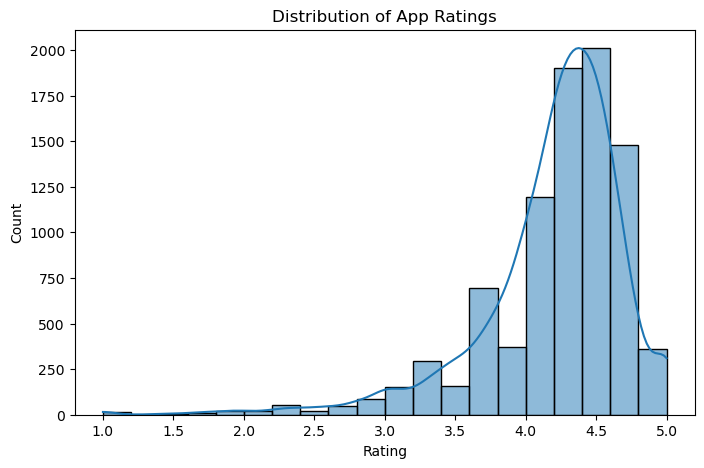

In [12]:

plt.figure(figsize=(8,5))

sns.histplot(
    df["Rating"],
    bins=20,
    kde=True
)

plt.title("Distribution of App Ratings")

plt.xlabel("Rating")

plt.show()

In [ ]:
# Business Insight

Most applications receive ratings between 4.0 and 4.5, suggesting generally positive user satisfaction

# Free vs Paid Apps

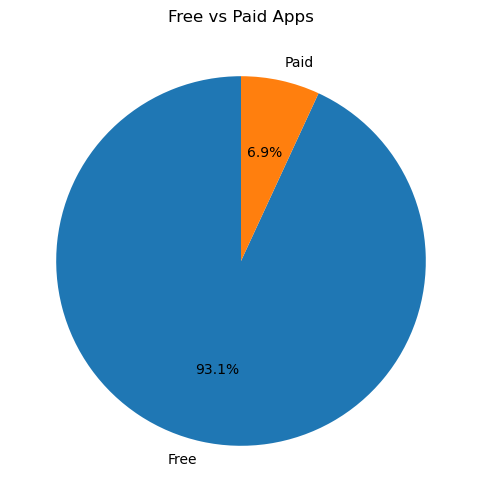

In [13]:


type_counts = df["Type"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Free vs Paid Apps")

plt.show()

In [ ]:
# Business Insight

Free applications dominate the Play Store.
Revenue often depends on ads or in-app purchases rather than upfront pricing.

# Top Categories by Installs

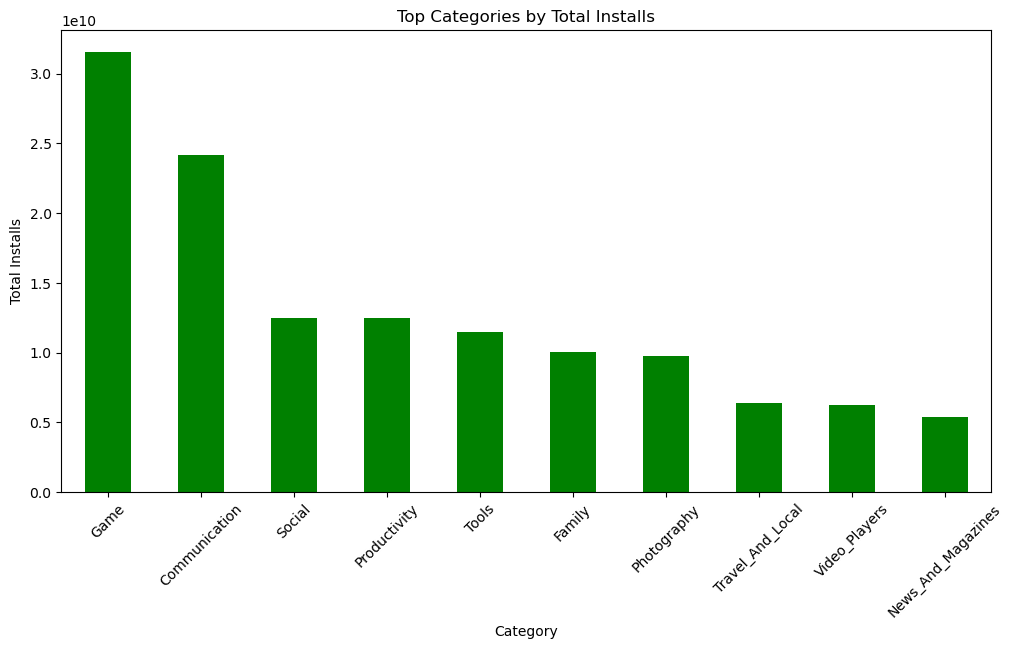

In [14]:
top_install = (
    df.groupby("Category")["Installs"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_install.plot(
    kind="bar",
    color="green"
)

plt.title("Top Categories by Total Installs")

plt.xlabel("Category")

plt.ylabel("Total Installs")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Business Insight

Categories with high install counts represent the largest customer base and highest market demand.

# Top Rated Categories

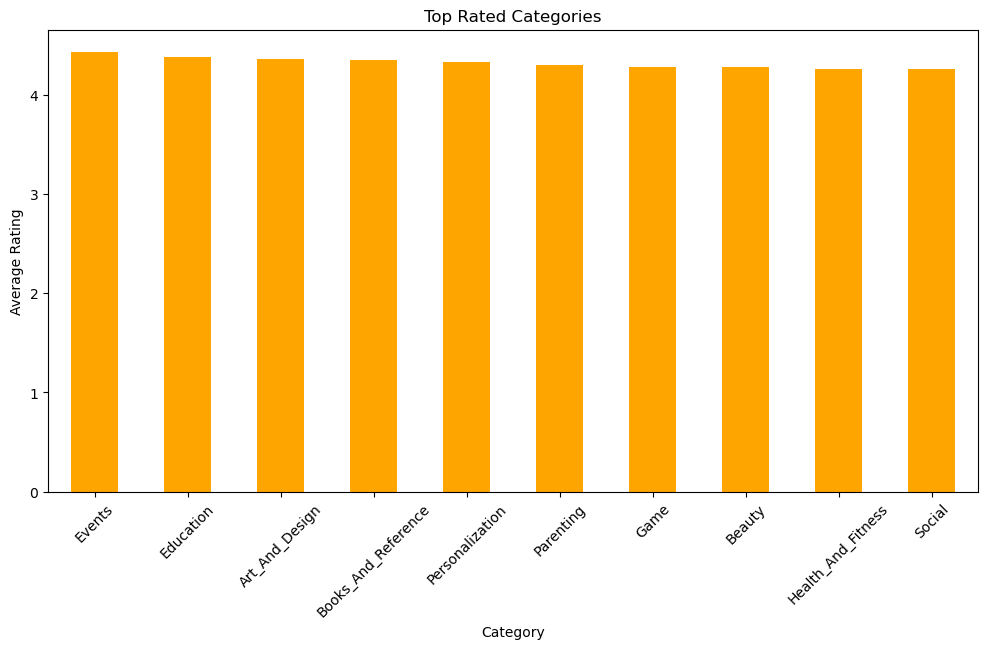

In [15]:
top_rating = (
    df.groupby("Category")["Rating"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_rating.plot(
    kind="bar",
    color="orange"
)

plt.title("Top Rated Categories")

plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Business Insight

High average ratings indicate strong user satisfaction and product quality.

# Reviews vs Rating

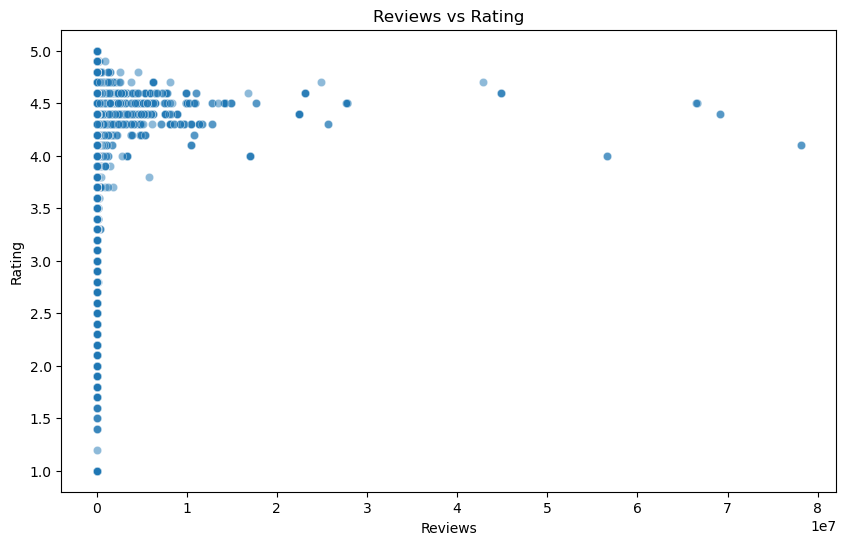

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Reviews",
    y="Rating",
    data=df,
    alpha=0.5
)

plt.title("Reviews vs Rating")

plt.show()

In [ ]:
# Business Insight

Determine whether highly reviewed applications also receive better ratings.

# Size Distribution

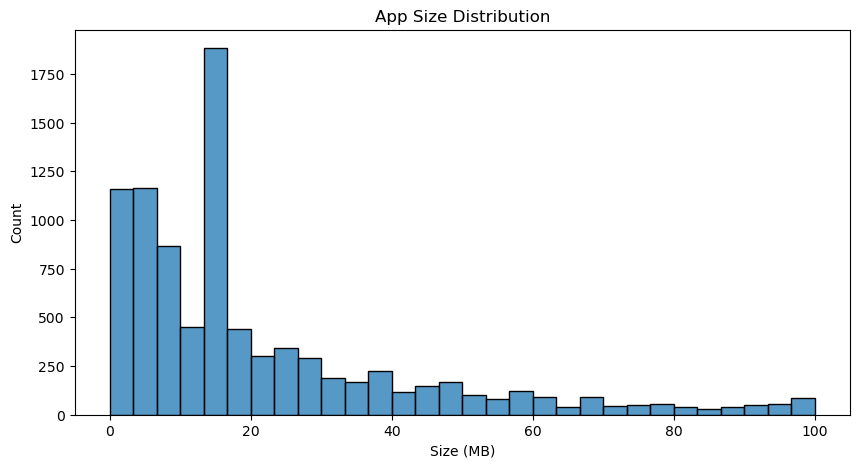

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Size"],
    bins=30
)

plt.title("App Size Distribution")

plt.xlabel("Size (MB)")

plt.show()

# Price Distribution

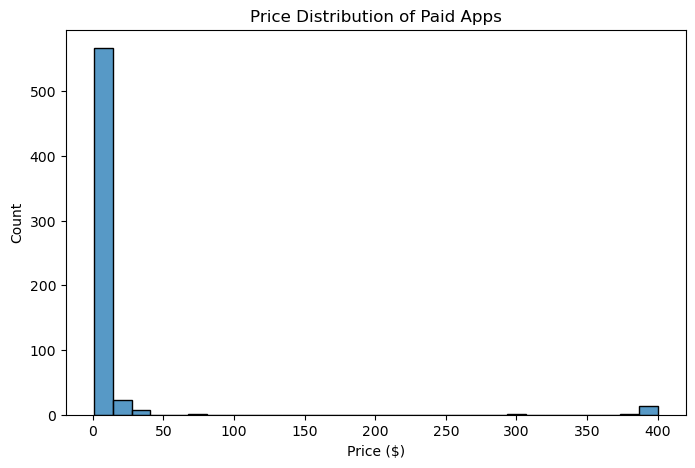

In [18]:
paid = df[df["Price"] > 0]

plt.figure(figsize=(8,5))

sns.histplot(
    paid["Price"],
    bins=30
)

plt.title("Price Distribution of Paid Apps")

plt.xlabel("Price ($)")

plt.show()

In [ ]:
# Business Insight

Most paid applications are priced at lower price points to encourage purchases.

# Rating by Category

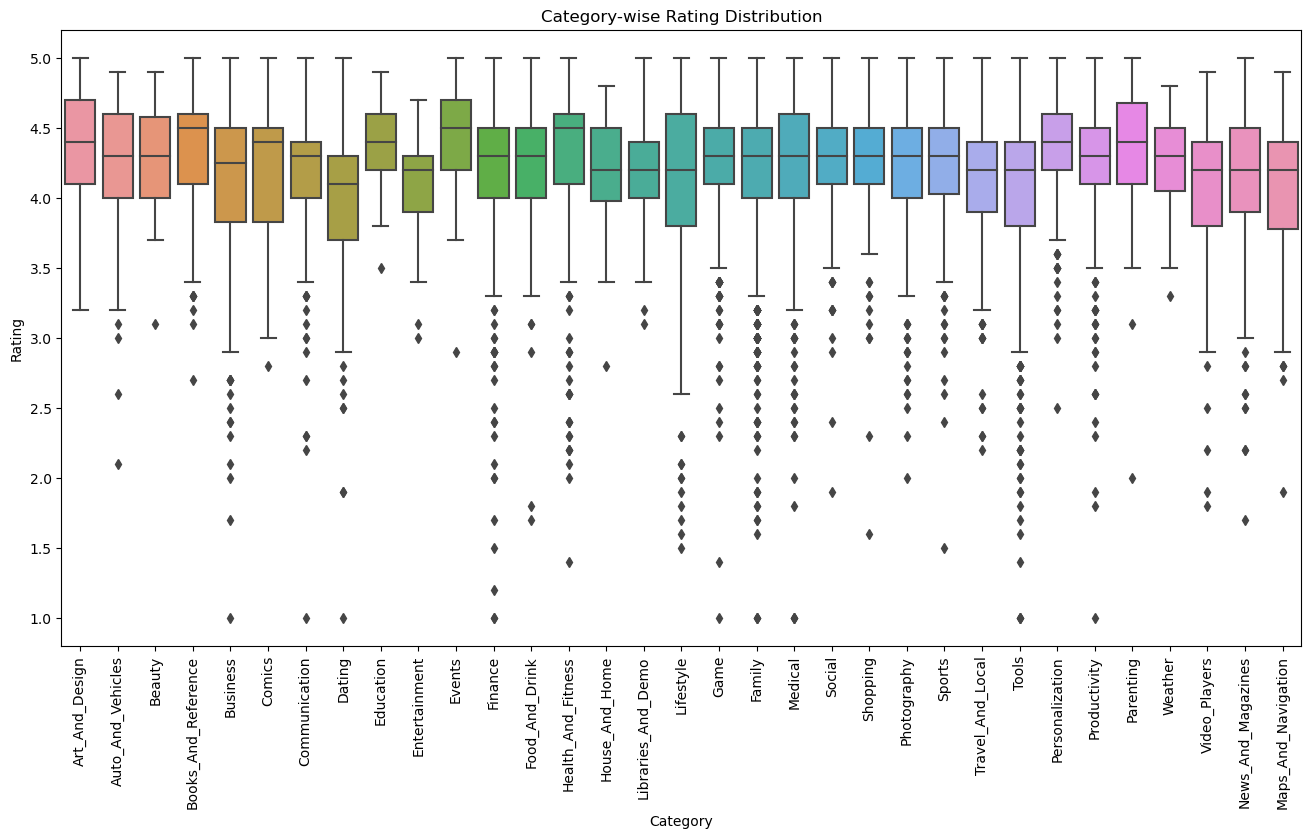

In [19]:
plt.figure(figsize=(16,8))

sns.boxplot(
    x="Category",
    y="Rating",
    data=df
)

plt.xticks(rotation=90)

plt.title("Category-wise Rating Distribution")

plt.show()

# Correlation Heatmap

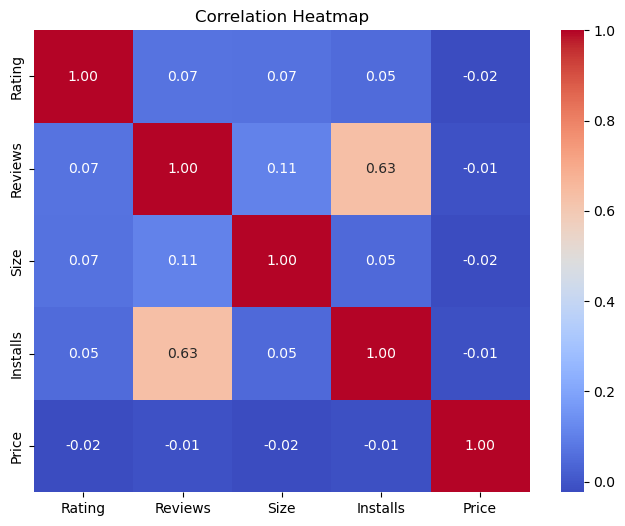

In [20]:
numeric = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# Business Insight

Examine relationships among installs, reviews, prices, ratings, and size.
Identify variables that tend to move together.

# Top Genres

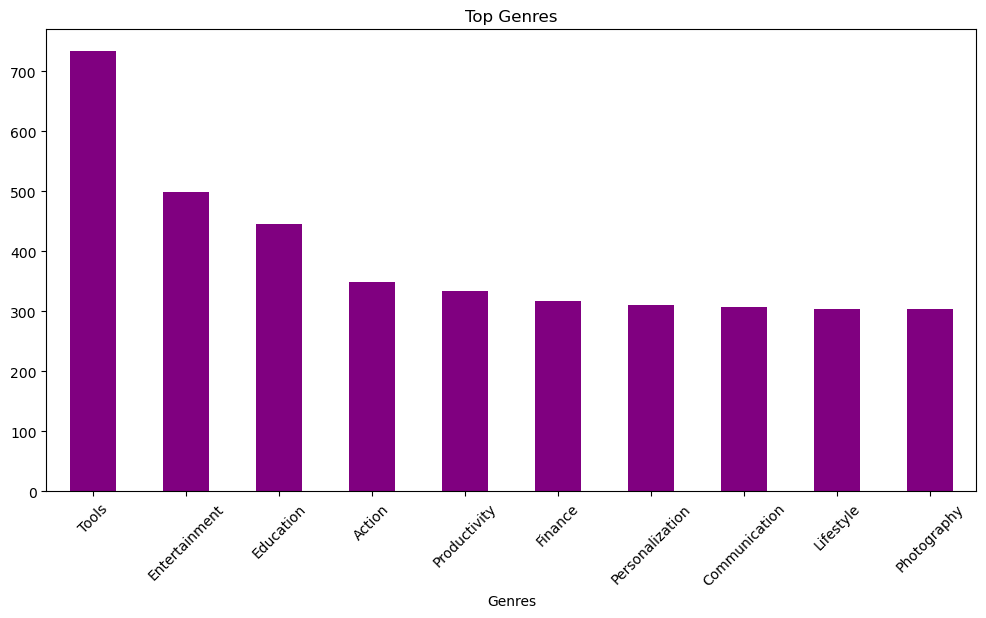

In [21]:
plt.figure(figsize=(12,6))

df["Genres"].value_counts().head(10).plot(
    kind="bar",
    color="purple"
)

plt.title("Top Genres")

plt.xticks(rotation=45)

plt.show()

# Apps Updated by Year

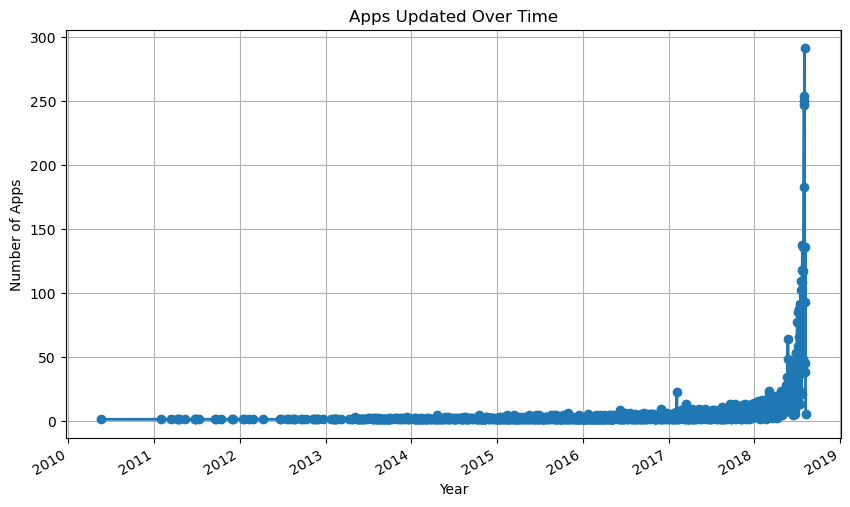

In [41]:
plt.figure(figsize=(10,6))

df["Last Updated"].value_counts().sort_index().plot(
    kind="line",
    marker="o",
    linewidth=2
)

plt.title("Apps Updated Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Apps")
plt.grid(True)

plt.show()

# Top 10 Most Reviewed Apps

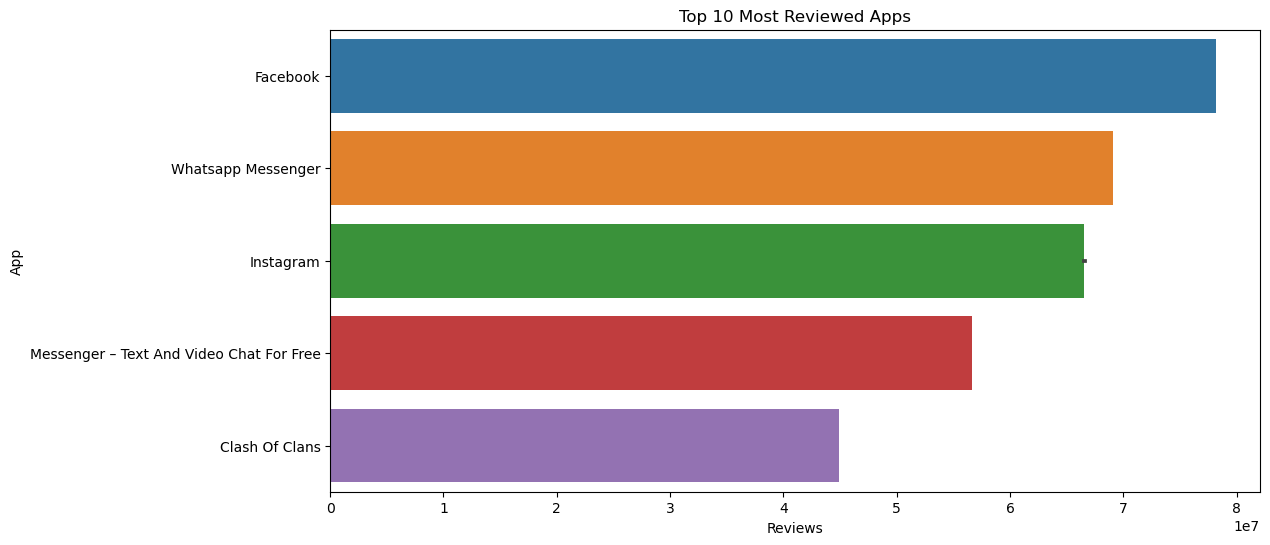

In [42]:
top_reviews = (
    df.sort_values("Reviews", ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x="Reviews",
    y="App",
    data=top_reviews
)

plt.title("Top 10 Most Reviewed Apps")

plt.show()